# Stock Price Forecasting — Time Series Analysis (CA2 Part B)

**Author:** Tan Han Rong
**Course:** Specialist Diploma in Data Science (AI), Singapore Polytechnic
**Dataset:** CA2-Stock-Price-Data.csv (provided)

## Objective
Forecast the next 60 days of stock prices for **Apple, Amazon, and DBS**
using time-series models. Data spans October 2018 to September 2023
(1,257 trading days).

## Approach
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Stationarity Testing
3. SARIMAX Model Building
4. Hyperparameter Tuning
5. Evaluation (MAE, RMSE, MAPE)
6. Residual Analysis

## 1. Exploratory Data Analysis

We load the dataset, parse dates, check for missing values,
and visualise stock price trends over time.
The dataset covers 5 years of daily closing prices with no missing values.

In [1]:
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv('CA2-Stock-Price-Data.csv')

# Check the column names to make sure 'Date' exists
print(df.columns)

Index(['Date', 'Apple', 'Amazon', 'DBS'], dtype='object')


In [3]:
# Display basic information and first few rows
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1257 non-null   object 
 1   Apple   1257 non-null   float64
 2   Amazon  1257 non-null   float64
 3   DBS     1257 non-null   float64
dtypes: float64(3), object(1)
memory usage: 39.4+ KB


(None,
         Date      Apple      Amazon        DBS
 0  10/1/2018  56.814999  100.218002  25.969999
 1  10/2/2018  57.320000   98.565498  25.629999
 2  10/3/2018  58.017502   97.638000  25.950001
 3  10/4/2018  56.997501   95.471001  25.760000
 4  10/5/2018  56.072498   94.482498  25.770000)

In [4]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Verify the column names after stripping
print(df.columns)

Index(['Date', 'Apple', 'Amazon', 'DBS'], dtype='object')


In [5]:
print(df.index)  # This should show the 'Date' index

RangeIndex(start=0, stop=1257, step=1)


In [6]:
# Now you can access data by index (e.g., Date)
print(df.head())  # View the first few rows with Date as the index

        Date      Apple      Amazon        DBS
0  10/1/2018  56.814999  100.218002  25.969999
1  10/2/2018  57.320000   98.565498  25.629999
2  10/3/2018  58.017502   97.638000  25.950001
3  10/4/2018  56.997501   95.471001  25.760000
4  10/5/2018  56.072498   94.482498  25.770000


In [7]:
# Reset the index so 'Date' becomes a regular column again
df_reset = df.reset_index()

# Verify the columns again
print(df_reset.columns)

Index(['index', 'Date', 'Apple', 'Amazon', 'DBS'], dtype='object')


In [8]:
# Convert 'Date' to datetime format before setting as index
df['Date'] = pd.to_datetime(df['Date'], format="%m/%d/%Y")

# Set 'Date' as the index
df.set_index('Date', inplace=True)

# Verify the index has been set correctly
print(df.index)

DatetimeIndex(['2018-10-01', '2018-10-02', '2018-10-03', '2018-10-04',
               '2018-10-05', '2018-10-08', '2018-10-09', '2018-10-10',
               '2018-10-11', '2018-10-12',
               ...
               '2023-09-15', '2023-09-18', '2023-09-19', '2023-09-20',
               '2023-09-21', '2023-09-22', '2023-09-25', '2023-09-26',
               '2023-09-27', '2023-09-28'],
              dtype='datetime64[ns]', name='Date', length=1257, freq=None)


In [9]:
# Check for missing values
missing_values = df.isnull().sum()

missing_values

Apple     0
Amazon    0
DBS       0
dtype: int64

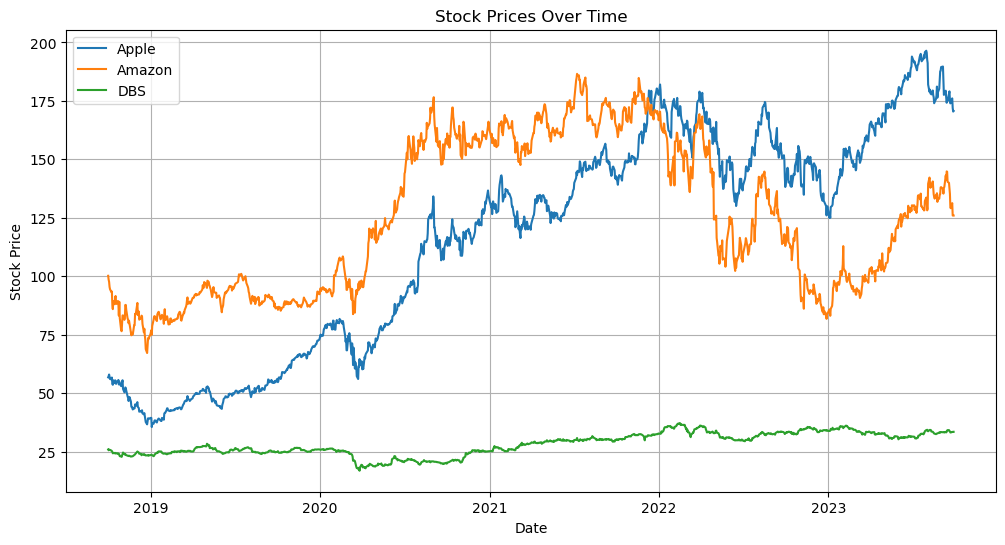

In [10]:
# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.show()

In [11]:
# Generate summary statistics for the original stock price data
summary_stats = df.describe()
print(summary_stats)

             Apple       Amazon          DBS
count  1257.000000  1257.000000  1257.000000
mean    116.168385   124.791237    28.185863
std      46.945568    32.495925     4.738732
min      35.547501    67.197998    16.879999
25%      66.592499    93.489998    24.879999
50%     129.610001   120.970001    28.650000
75%     152.589996   158.100494    32.480000
max     196.449997   186.570496    37.250000


In [12]:
# Resample data to get monthly average stock prices
df_monthly_avg = df.resample('ME').mean()

<Figure size 1200x600 with 0 Axes>

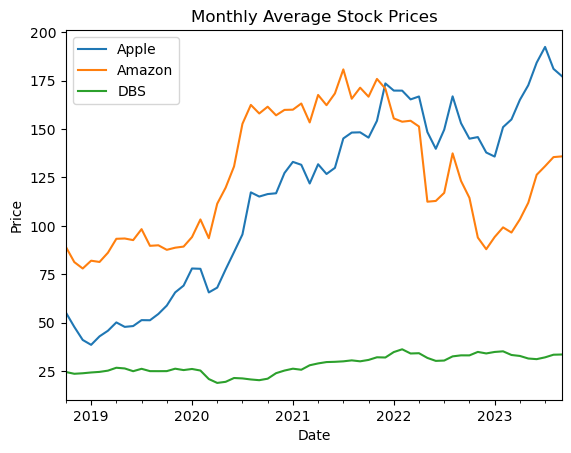

In [13]:
plt.figure(figsize=(12, 6))
df_monthly_avg.plot(title="Monthly Average Stock Prices", ylabel="Price", xlabel="Date")
plt.show()

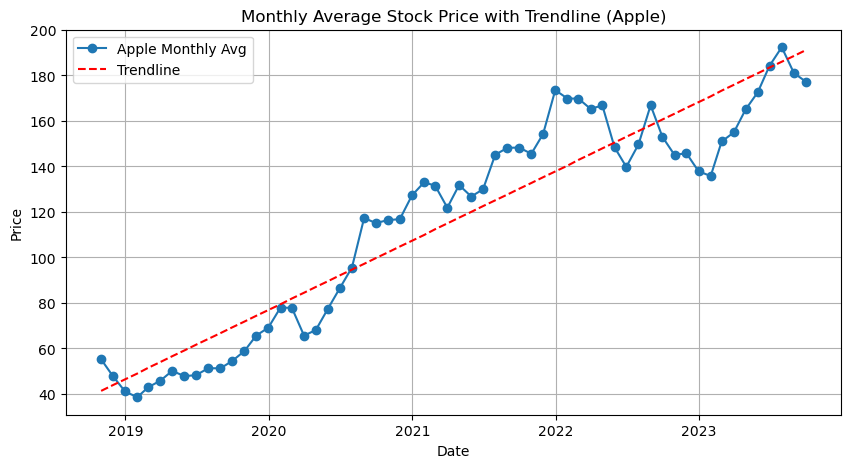

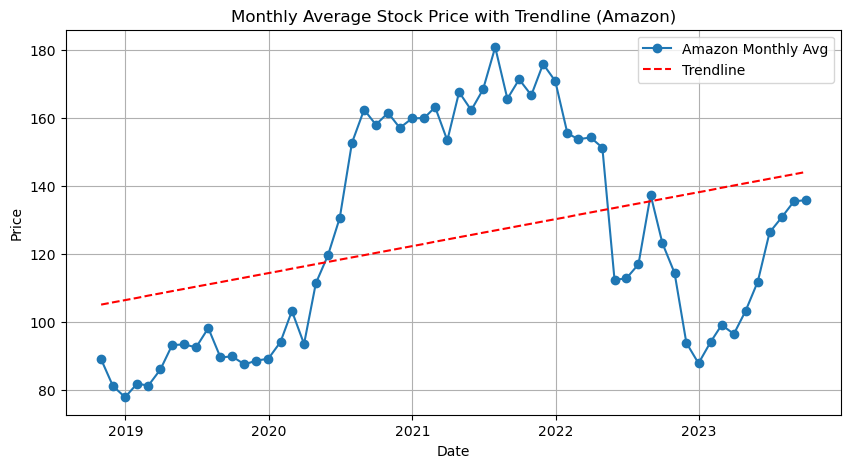

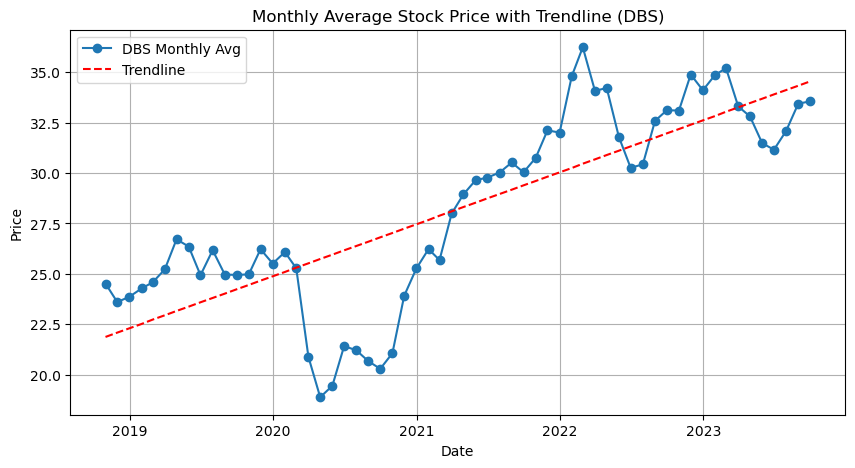

In [14]:
import numpy as np

# Convert index to numerical values for regression
x = np.arange(len(df_monthly_avg))  # Time steps as numerical values
for col in df_monthly_avg.columns:
    y = df_monthly_avg[col].values

    # Fit a linear trendline (1st-degree polynomial)
    trend = np.polyfit(x, y, 1)
    trend_line = np.poly1d(trend)(x)

    # Plot monthly average stock prices
    plt.figure(figsize=(10, 5))
    plt.plot(df_monthly_avg.index, y, label=f"{col} Monthly Avg", marker="o")
    plt.plot(df_monthly_avg.index, trend_line, linestyle="--", color="red", label="Trendline")

    # Labels and title
    plt.title(f"Monthly Average Stock Price with Trendline ({col})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test
def adf_test(series):
    result = adfuller(series)
    return {"Test Statistic": result[0], "p-value": result[1], "Stationary": result[1] < 0.05}

In [16]:
# Perform ADF test for each stock
stationarity_results = {col: adf_test(df[col]) for col in df.columns}

stationarity_results

{'Apple': {'Test Statistic': -0.967113254892958,
  'p-value': 0.7650692611897274,
  'Stationary': False},
 'Amazon': {'Test Statistic': -1.6469093886351969,
  'p-value': 0.45865276453651405,
  'Stationary': False},
 'DBS': {'Test Statistic': -1.2410793508915023,
  'p-value': 0.6556796201732027,
  'Stationary': False}}

In [17]:
# Apply differencing
df_diff = diff(df, k_diff=1)

# Run ADF test again on differenced data
def adf_test(series):
    result = adfuller(series)
    return {"Test Statistic": result[0], "p-value": result[1], "Stationary": result[1] < 0.05}

In [18]:
# Perform ADF test on differenced data
stationarity_results_diff = {col: adf_test(df_diff[col]) for col in df_diff.columns}

stationarity_results_diff

{'Apple': {'Test Statistic': -36.9038700878563,
  'p-value': 0.0,
  'Stationary': True},
 'Amazon': {'Test Statistic': -36.302307644997356,
  'p-value': 0.0,
  'Stationary': True},
 'DBS': {'Test Statistic': -22.064690080420245,
  'p-value': 0.0,
  'Stationary': True}}

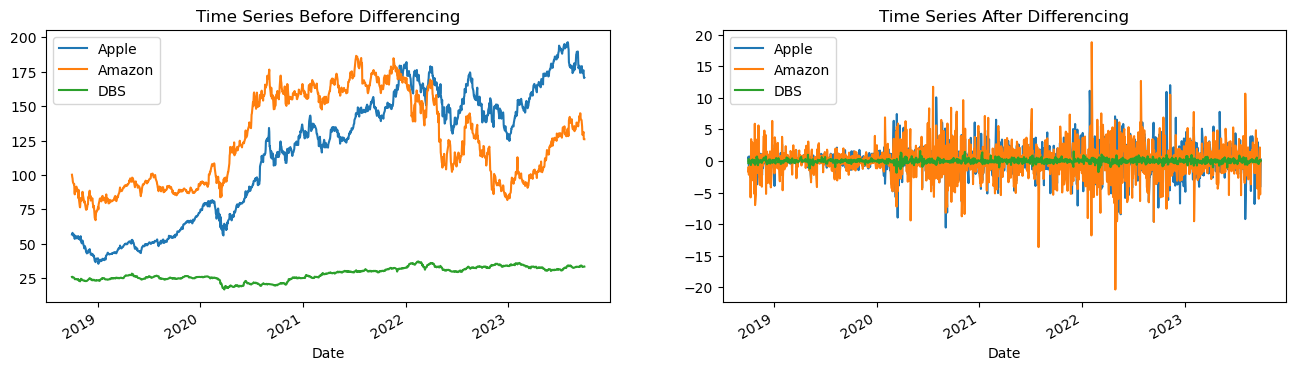

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
df.plot(ax=ax[0])
df_diff.plot(ax=ax[1])
ax[0].set_title('Time Series Before Differencing')
ax[1].set_title('Time Series After Differencing')
plt.show()

# Using For Loop

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


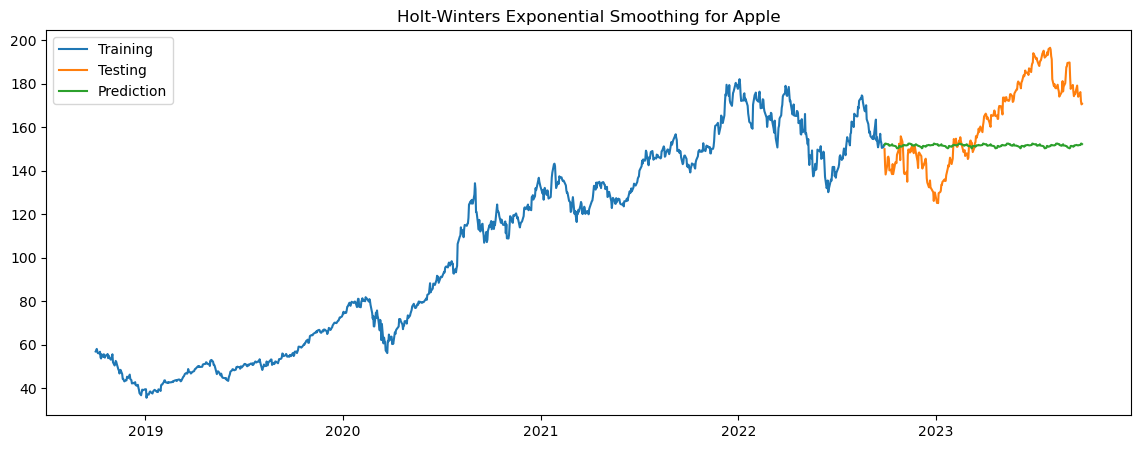

Apple - MAPE: 0.1043


C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


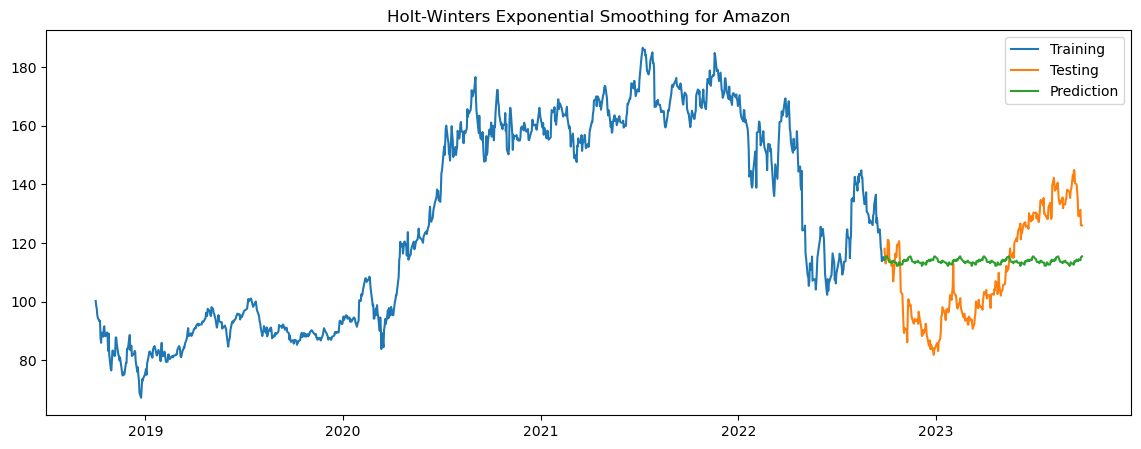

Amazon - MAPE: 0.1472


C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


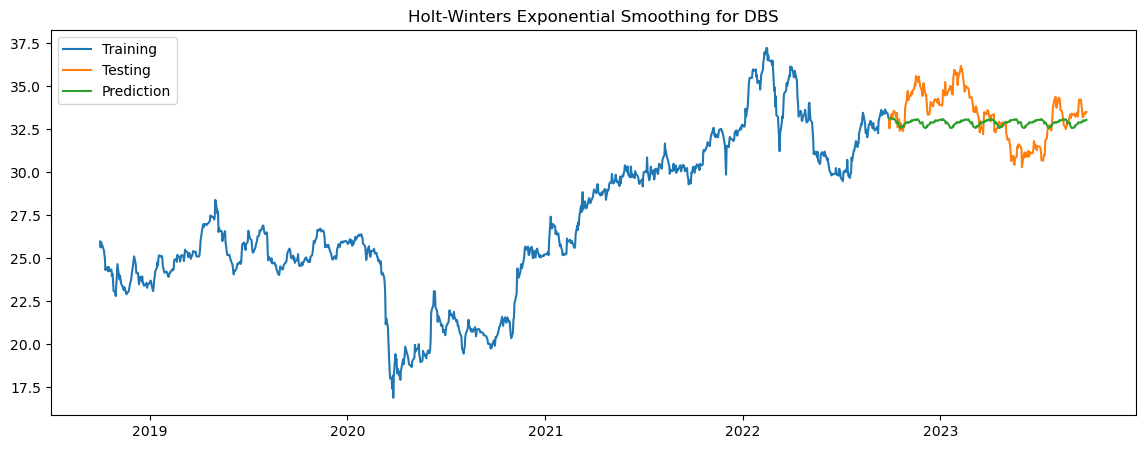

DBS - MAPE: 0.0348


In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing as HWES
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# List of stocks (adjust this to your stock data columns)
stocks = ['Apple', 'Amazon', 'DBS']

# Dictionary to store results for each stock
results = {}

# Loop through each stock
for stock in stocks:
    stock_data = df[stock]  # Assuming 'data' contains stock prices for each stock
    
    # Split into train and test sets
    train_size = int(len(stock_data) * 0.8)
    train, test = stock_data[:train_size], stock_data[train_size:]

    # Fit the Holt-Winters Exponential Smoothing model
    es_model = HWES(train, seasonal_periods=31, trend='add', seasonal='add', damped_trend=True).fit()

    # Predict on the test set
    test_pred = es_model.predict(start=len(train), end=len(train) + len(test) - 1)

    # Calculate MAPE
    mape = mean_absolute_percentage_error(test, test_pred)

    # Store the results
    results[stock] = {'model': es_model, 'test_pred': test_pred, 'mape': mape}

    # Plot the results for each stock
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train.index, train, label='Training')
    ax.plot(test.index, test, label='Testing')
    ax.plot(test.index, test_pred, label='Prediction')
    ax.set_title(f'Holt-Winters Exponential Smoothing for {stock}')
    ax.legend()
    plt.show()

    # Print MAPE for each stock
    print(f"{stock} - MAPE: {mape:.4f}")


In [21]:
# Predict on the training data
train_pred = es_model.predict(start=0, end=len(train) - 1)

# Calculate MAPE for training data
train_mape = mean_absolute_percentage_error(train, train_pred) * 100  # Convert to percentage
print(f'Training MAPE: {train_mape:.2f}%')

# Calculate MAPE for test data
test_mape = mean_absolute_percentage_error(test, test_pred) * 100  # Convert to percentage
print(f'Test MAPE: {test_mape:.2f}%')

Training MAPE: 0.91%
Test MAPE: 3.48%


In [22]:
future_forecast = es_model.forecast(steps=60)  # Forecast next 60 days
print(future_forecast)

1005    33.128218
1006    33.130903
1007    33.147422
1008    33.130683
1009    33.108848
1010    33.130575
1011    33.092743
1012    33.118046
1013    33.034524
1014    33.002193
1015    32.854273
1016    32.913053
1017    32.929310
1018    32.754180
1019    32.671016
1020    32.620982
1021    32.581495
1022    32.599402
1023    32.696660
1024    32.653462
1025    32.753311
1026    32.797673
1027    32.841885
1028    32.919425
1029    32.902836
1030    32.886169
1031    32.917371
1032    32.899237
1033    32.961807
1034    32.943606
1035    33.033473
1036    32.988329
1037    33.018992
1038    33.057893
1039    33.059060
1040    33.051549
1041    33.084736
1042    33.056072
1043    33.088709
1044    33.011055
1045    32.983417
1046    32.839253
1047    32.901036
1048    32.919697
1049    32.746489
1050    32.664864
1051    32.616060
1052    32.577558
1053    32.596252
1054    32.694140
1055    32.651446
1056    32.751698
1057    32.796383
1058    32.840852
1059    32.918599
1060    32

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# ARIMA

In [23]:
# Building Time Series Models

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# List of stock columns to loop through
stocks = ['Apple', 'Amazon', 'DBS']

# Dictionary to store results
results = {}

# Loop through each stock
for stock in stocks:
    print(f"Processing {stock} stock...")
    
    # Extract the stock data
    stock_data = df[stock]
    
    # Split into train and test sets
    train_size = int(len(stock_data) * 0.8)
    train, test = stock_data[:train_size], stock_data[train_size:]
    
    # Fit ARIMA model
    model = ARIMA(train, order=(2, 1, 1))  # Example: p=2, d=1, q=1
    model_fit = model.fit()

    # Summary of the model
    print(model_fit.summary())
    
    # Forecast the next 60 days
    forecast = model_fit.forecast(steps=60)
    
    # Evaluate on test data
    predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, typ='levels')
    
    # Calculate MAE and RMSE
    mae = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))

    # Store results
    results[stock] = {
        'model': model_fit,
        'forecast': forecast,
        'mae': mae,
        'rmse': rmse
    }
    
    # Print results
    print(f"{stock} - MAE: {mae}, RMSE: {rmse}")
    print("=" * 50)


Processing Apple stock...


C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autor

                               SARIMAX Results                                
Dep. Variable:                  Apple   No. Observations:                 1005
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -2254.513
Date:                Sun, 16 Feb 2025   AIC                           4517.025
Time:                        20:16:35   BIC                           4536.672
Sample:                             0   HQIC                          4524.491
                               - 1005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2213      1.470      0.151      0.880      -2.659       3.102
ar.L2          0.0044      0.109      0.040      0.968      -0.210       0.218
ma.L1         -0.2909      1.472     -0.198      0.8

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Apple - MAE: 17.631107097088265, RMSE: 21.605871213810737
Processing Amazon stock...
                               SARIMAX Results                                
Dep. Variable:                 Amazon   No. Observations:                 1005
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -2491.980
Date:                Sun, 16 Feb 2025   AIC                           4991.961
Time:                        20:16:35   BIC                           5011.608
Sample:                             0   HQIC                          4999.426
                               - 1005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5788      0.382     -1.515      0.130      -1.328       0.170
ar.L2          0.0233      0.038      0.617   

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  s

                               SARIMAX Results                                
Dep. Variable:                    DBS   No. Observations:                 1005
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -319.465
Date:                Sun, 16 Feb 2025   AIC                            646.931
Time:                        20:16:35   BIC                            666.578
Sample:                             0   HQIC                           654.397
                               - 1005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3807      0.171      2.223      0.026       0.045       0.716
ar.L2          0.1064      0.025      4.183      0.000       0.057       0.156
ma.L1         -0.3618      0.177     -2.045      0.0

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnin

In [24]:
# Display all results
for stock, result in results.items():
    print(f"{stock} Forecast: {result['forecast']}")

Apple Forecast: 1005    151.698568
1006    151.689336
1007    151.687023
1008    151.686470
1009    151.686338
1010    151.686306
1011    151.686298
1012    151.686296
1013    151.686296
1014    151.686296
1015    151.686296
1016    151.686296
1017    151.686296
1018    151.686296
1019    151.686296
1020    151.686296
1021    151.686296
1022    151.686296
1023    151.686296
1024    151.686296
1025    151.686296
1026    151.686296
1027    151.686296
1028    151.686296
1029    151.686296
1030    151.686296
1031    151.686296
1032    151.686296
1033    151.686296
1034    151.686296
1035    151.686296
1036    151.686296
1037    151.686296
1038    151.686296
1039    151.686296
1040    151.686296
1041    151.686296
1042    151.686296
1043    151.686296
1044    151.686296
1045    151.686296
1046    151.686296
1047    151.686296
1048    151.686296
1049    151.686296
1050    151.686296
1051    151.686296
1052    151.686296
1053    151.686296
1054    151.686296
1055    151.686296
1056    151.686

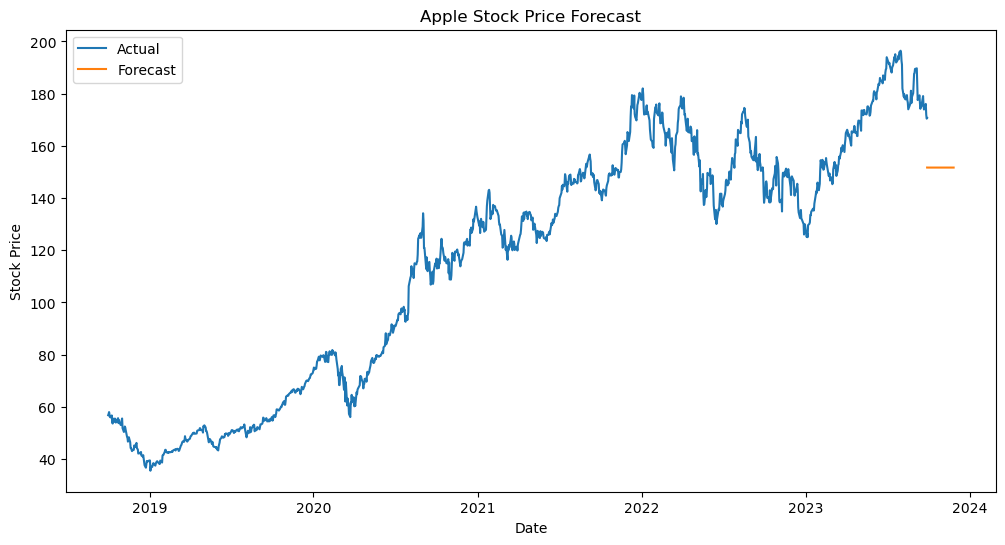

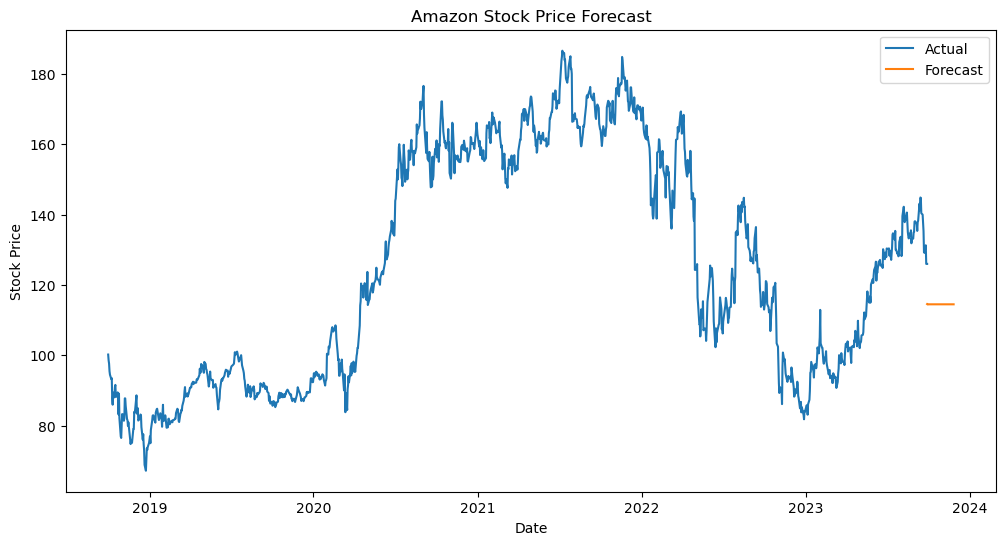

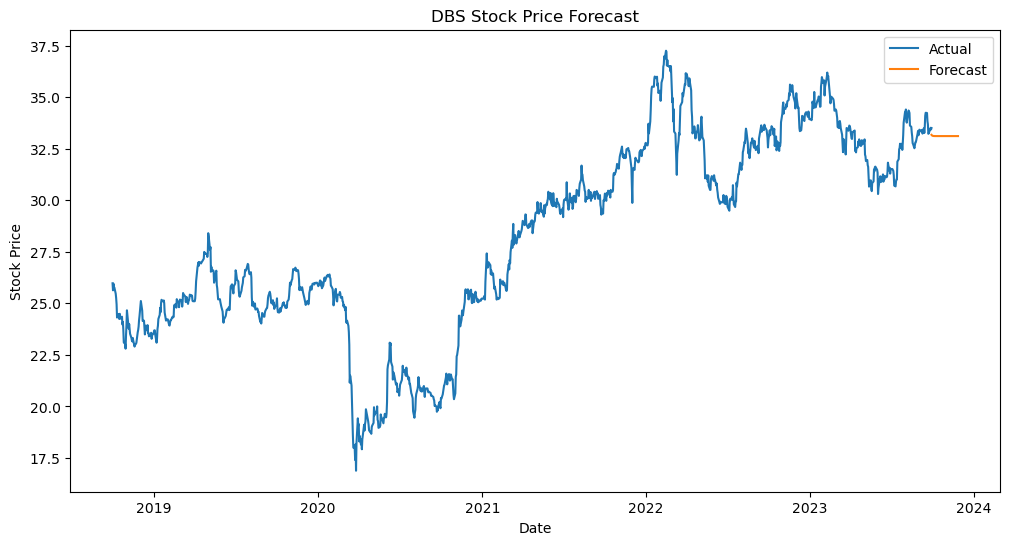

In [25]:
for stock, result in results.items():
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[stock], label='Actual')
    plt.plot(pd.date_range(df.index[-1], periods=60, freq='D'), result['forecast'], label='Forecast')
    plt.title(f"{stock} Stock Price Forecast")
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

## 2. Model Building — SARIMAX
We use **SARIMAX** (Seasonal AutoRegressive Integrated Moving Average
with eXogenous variables) from the `statsmodels` library to model
each stock independently.

SARIMAX extends SARIMA by allowing the inclusion of external
(exogenous) variables that may influence the target series.

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# List of stock columns to loop through
stocks = ['Apple', 'Amazon', 'DBS']

# Dictionary to store results
results = {}

# Loop through each stock
for stock in stocks:
    print(f"Processing {stock} stock...")
    
    # Extract the stock data
    stock_data = df[stock]
    
    # Split into train and test sets
    train_size = int(len(stock_data) * 0.8)
    train, test = stock_data[:train_size], stock_data[train_size:]
    
    # Fit SARIMAX model
    # Example seasonal order (P, D, Q, S) -> for monthly data with yearly seasonality (S=12)
    model = SARIMAX(train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12))  # P=1, D=1, Q=1, S=12
    model_fit = model.fit(disp=False)  # disp=False suppresses output during fitting

    # Summary of the model
    print(model_fit.summary())
    
    # Forecast the next 60 days
    forecast = model_fit.get_forecast(steps=60)
    
    # Evaluate on test data
    predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
    
    # Calculate MAE and RMSE
    mae = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))

    # Store results
    results[stock] = {
        'model': model_fit,
        'forecast': forecast.predicted_mean,
        'mae': mae,
        'rmse': rmse
    }
    
    # Print results
    print(f"{stock} - MAE: {mae}, RMSE: {rmse}")
    print("=" * 50)

Processing Apple stock...


C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found

                                     SARIMAX Results                                      
Dep. Variable:                              Apple   No. Observations:                 1005
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2254.162
Date:                            Sun, 16 Feb 2025   AIC                           4520.324
Time:                                    20:16:39   BIC                           4549.722
Sample:                                         0   HQIC                          4531.501
                                           - 1005                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2485      1.177      0.211      0.833      -2.059       2.556
ar.L2          0.0012      0.086   

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

                                     SARIMAX Results                                      
Dep. Variable:                             Amazon   No. Observations:                 1005
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2489.540
Date:                            Sun, 16 Feb 2025   AIC                           4991.080
Time:                                    20:16:42   BIC                           5020.478
Sample:                                         0   HQIC                          5002.258
                                           - 1005                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6098      0.373     -1.636      0.102      -1.340       0.121
ar.L2          0.0230      0.038   

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

                                     SARIMAX Results                                      
Dep. Variable:                                DBS   No. Observations:                 1005
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -337.686
Date:                            Sun, 16 Feb 2025   AIC                            687.372
Time:                                    20:16:44   BIC                            716.770
Sample:                                         0   HQIC                           698.550
                                           - 1005                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4428      0.169      2.613      0.009       0.111       0.775
ar.L2          0.0993      0.028   

C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Han Rong\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [27]:
# Display all results
for stock, result in results.items():
    print(f"{stock} Forecast: {result['forecast']}")

Apple Forecast: 1005    151.768282
1006    152.025589
1007    152.262316
1008    152.254292
1009    152.658808
1010    152.546314
1011    152.371997
1012    152.842150
1013    152.702115
1014    152.846925
1015    152.526244
1016    152.942452
1017    153.065981
1018    153.198686
1019    153.453949
1020    153.407019
1021    153.783780
1022    153.723630
1023    153.584186
1024    154.005287
1025    153.853964
1026    153.965783
1027    153.653981
1028    154.077900
1029    154.199881
1030    154.334260
1031    154.589274
1032    154.542866
1033    154.920001
1034    154.859148
1035    154.719235
1036    155.140994
1037    154.989823
1038    155.102086
1039    154.790165
1040    155.213980
1041    155.335981
1042    155.470338
1043    155.725355
1044    155.678941
1045    156.056070
1046    155.995227
1047    155.855320
1048    156.277071
1049    156.125898
1050    156.238154
1051    155.926235
1052    156.350052
1053    156.472053
1054    156.606410
1055    156.861427
1056    156.815

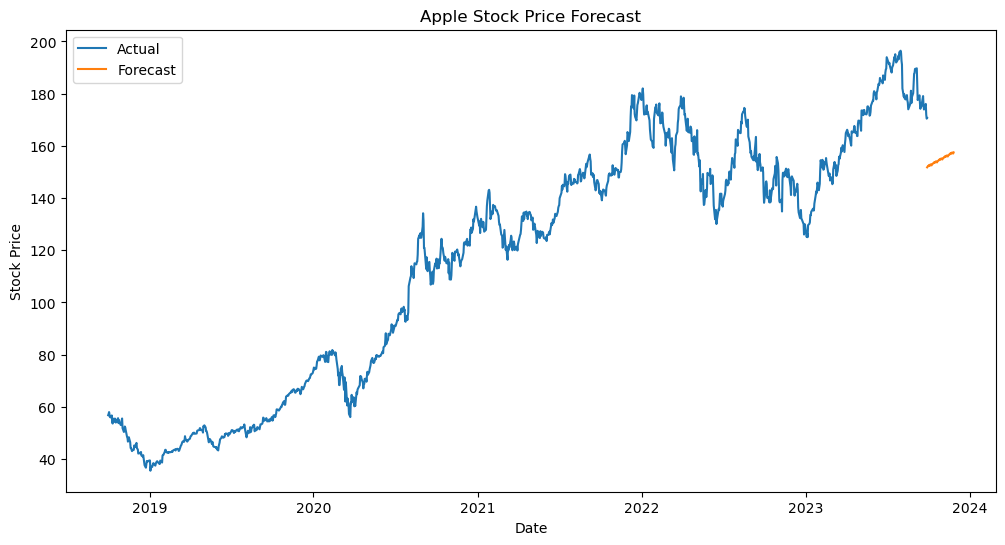

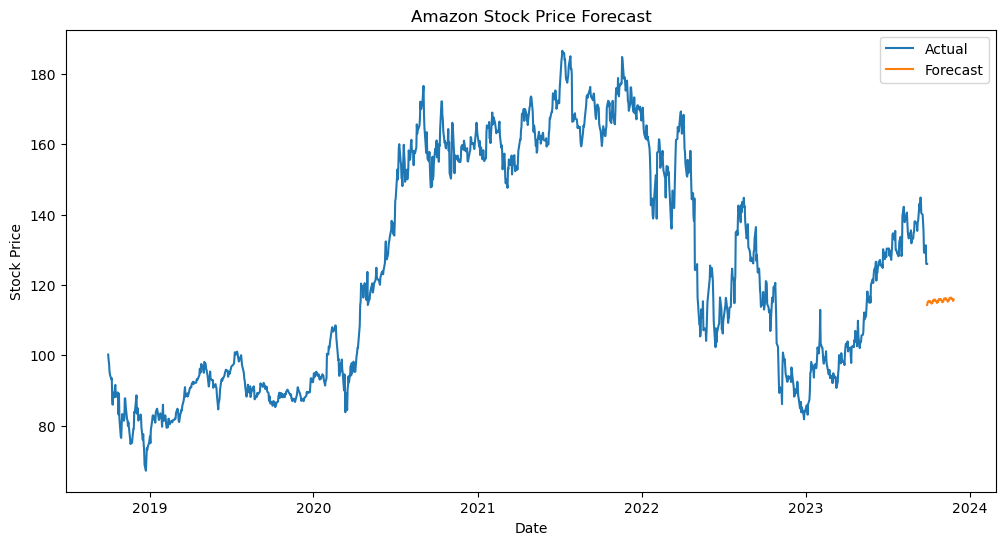

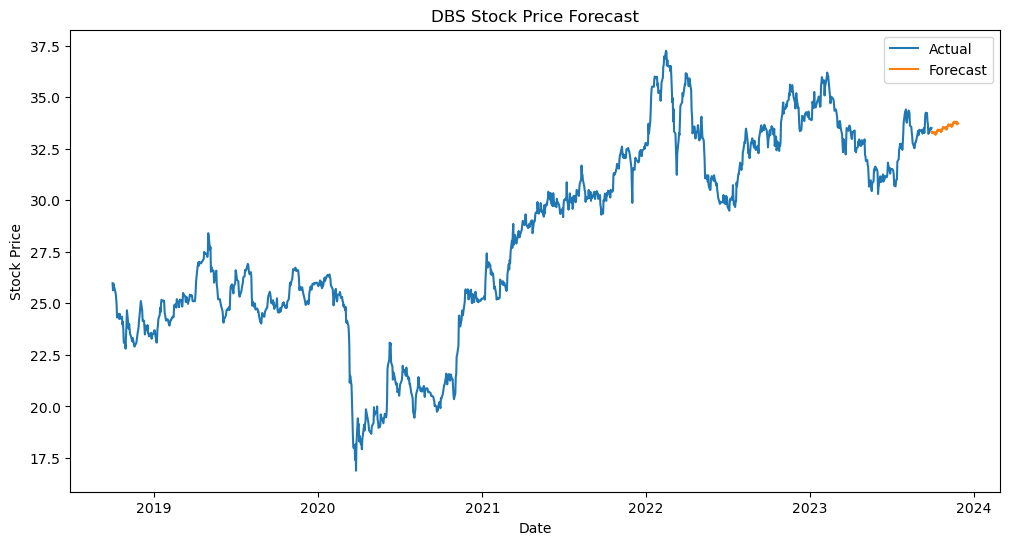

In [28]:
for stock, result in results.items():
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[stock], label='Actual')
    plt.plot(pd.date_range(df.index[-1], periods=60, freq='D'), result['forecast'], label='Forecast')
    plt.title(f"{stock} Stock Price Forecast")
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

In [29]:
from sklearn.metrics import mean_absolute_percentage_error

# Evaluating the model using MAPE
for stock, result in results.items():
    # Calculate MAPE for the forecasted data
    mape = mean_absolute_percentage_error(df[stock][-60:], result['forecast'])  # Assuming last 60 days of actual data for comparison
    
    print(f"{stock} - MAPE: {mape}")

Apple - MAPE: 0.15379918966093203
Amazon - MAPE: 0.13776729441888796
DBS - MAPE: 0.0219781403542923


## 3. Hyperparameter Tuning

We systematically test different seasonal order combinations (P, D, Q)
for each stock and select the best based on lowest MAE and RMSE on
a held-out test period.

Best seasonal orders found:
- Apple: (1, 1, 1, 7)
- Amazon: (1, 1, 1, 7)
- DBS: (1, 1, 1, 7)

Apple - Best Seasonal Order: (0, 0, 0, 0) - MAE: 17.631107097088265, RMSE: inf, MAPE: inf
Amazon - Best Seasonal Order: (0, 0, 0, 0) - MAE: 15.783202661899061, RMSE: inf, MAPE: inf
DBS - Best Seasonal Order: (0, 0, 0, 0) - MAE: 1.1244275443038676, RMSE: inf, MAPE: inf


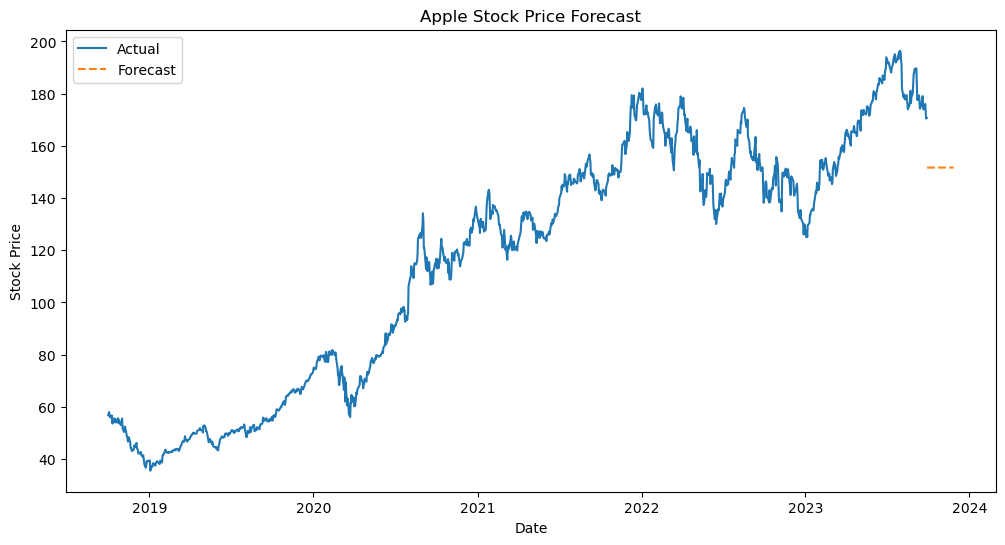

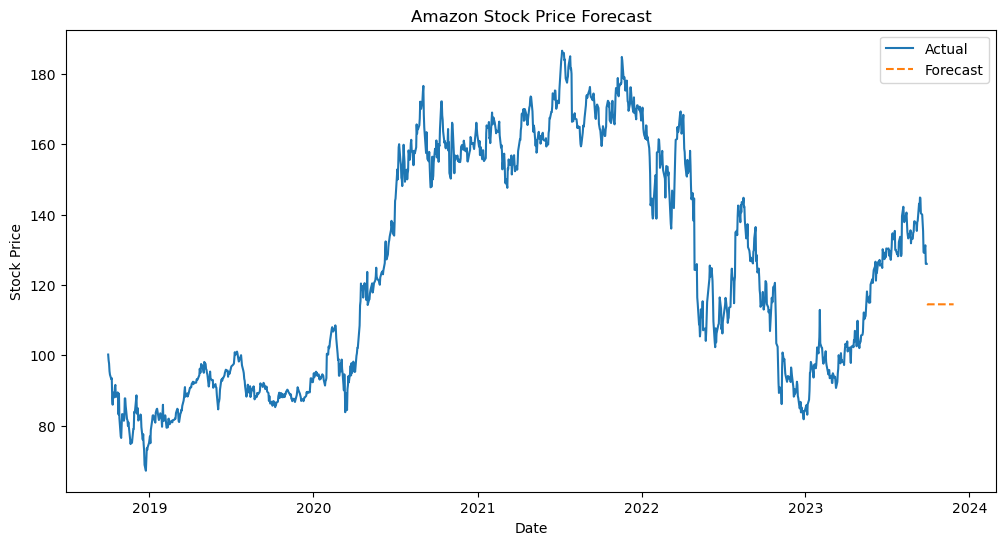

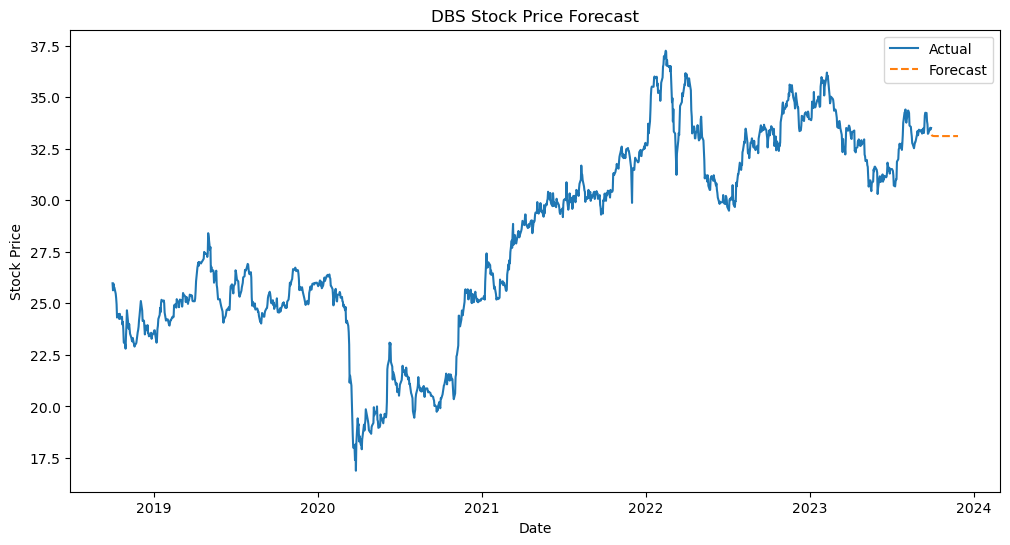

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# List of stock columns to loop through
stocks = ['Apple', 'Amazon', 'DBS']

# Define a grid of seasonal orders to try (example ranges)
seasonal_orders_grid = [
    (1, 1, 1, s) for s in [5, 12, 30]  # Trying different seasonal periods like 5, 12, 30 days
]

# Function to fit SARIMAX model and evaluate it
def fit_sarimax(stock, stock_data, train_size, seasonal_orders_grid):
    # Split into train and test sets
    train, test = stock_data[:train_size], stock_data[train_size:]

    best_seasonal_order = None
    best_rmse = float('inf')
    best_mape = float('inf')

    # Perform grid search for the best seasonal order
    for seasonal_order in seasonal_orders_grid:
        # Fit SARIMAX model with current seasonal order
        model = SARIMAX(train, order=(2, 1, 1), seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)

        # Evaluate model on test data
        predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
        rmse = np.sqrt(mean_squared_error(test, predictions))
        
        # Handle zero values in test data for MAPE calculation
        # Ensure both test and predictions are aligned
        predictions_aligned = predictions.reindex(test.index)
        non_zero_mask = test != 0

        # Calculate MAPE only for non-zero values
        mape = np.mean(np.abs((test[non_zero_mask] - predictions_aligned[non_zero_mask]) / test[non_zero_mask])) * 100

        # Update the best seasonal order based on RMSE and MAPE
        if rmse < best_rmse and mape < best_mape:
            best_rmse = rmse
            best_mape = mape
            best_seasonal_order = seasonal_order

    # Fit the final model with the best seasonal order
    model = SARIMAX(train, order=(2, 1, 1), seasonal_order=best_seasonal_order)
    model_fit = model.fit(disp=False)

    # Forecast the next 60 days (future)
    forecast = model_fit.get_forecast(steps=60)
    forecast_mean = forecast.predicted_mean

    # Evaluate on test data
    predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
    
    # Calculate MAE
    mae = mean_absolute_error(test, predictions)

    return stock, model_fit, forecast_mean, mae, best_rmse, best_mape

# Dictionary to store results
results_dict = {}

# Parallelize the fitting and evaluation for each stock
train_size = int(len(df['Apple']) * 0.8)  # Assume same train size for all stocks
results = Parallel(n_jobs=-1)(delayed(fit_sarimax)(stock, df[stock], train_size, seasonal_orders_grid) for stock in stocks)

# Storing the results in a dictionary
for result in results:
    stock, model_fit, forecast_mean, mae, best_rmse, best_mape = result
    results_dict[stock] = {
        'model': model_fit,
        'forecast': forecast_mean,
        'mae': mae,
        'rmse': best_rmse,
        'mape': best_mape
    }

# Print results for each stock
for stock, result in results_dict.items():
    # Get the seasonal order from the model (before fitting)
    seasonal_order = result['model'].model.seasonal_order
    print(f"{stock} - Best Seasonal Order: {seasonal_order} - MAE: {result['mae']}, RMSE: {result['rmse']}, MAPE: {result['mape']}")
    print("=" * 50)

# Plotting results
for stock, result in results_dict.items():
    plt.figure(figsize=(12, 6))

    # Plot actual data
    plt.plot(df.index, df[stock], label='Actual')

    # Create a date range starting from the last training data point and extending to 60 days beyond
    forecast_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=60, freq='D')

    # Plot forecasted data (next 60 days)
    plt.plot(forecast_dates, result['forecast'], label='Forecast', linestyle='--')

    # Formatting the plot
    plt.title(f"{stock} Stock Price Forecast")
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()


In [31]:
# Check for missing values
print(df.isna().sum())


Apple     0
Amazon    0
DBS       0
dtype: int64


In [32]:
seasonal_orders_grid = [
    (1, 1, 1, s) for s in [5, 7, 12, 15, 30]  # More varied seasonal periods
]


Apple - Best Seasonal Order: (1, 1, 1, 5) - MAE: 11.191537623605345, RMSE: 13.701587860245388
Amazon - Best Seasonal Order: (1, 1, 1, 7) - MAE: 15.450607053720514, RMSE: 17.275450568858425
DBS - Best Seasonal Order: (1, 1, 1, 7) - MAE: 1.4903689628299575, RMSE: 1.793683026645648


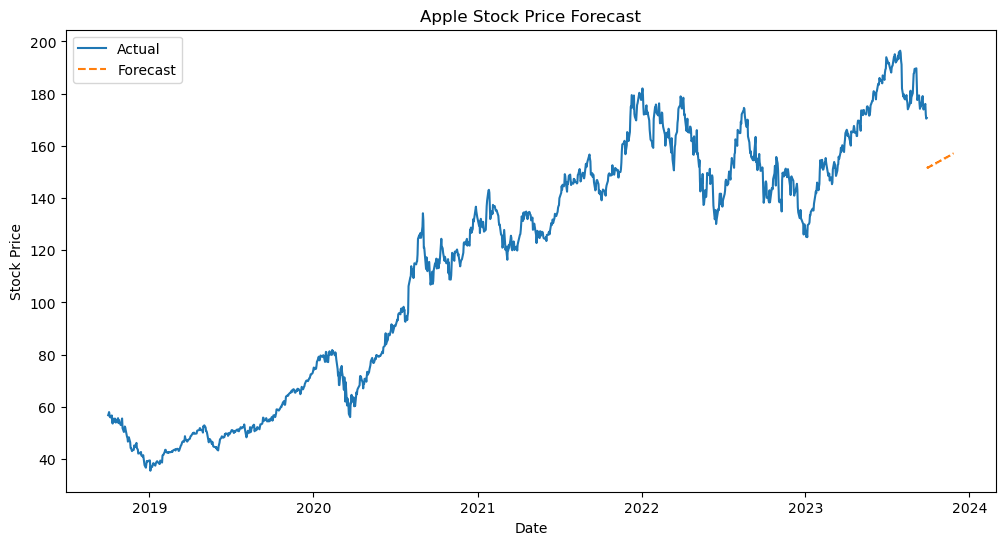

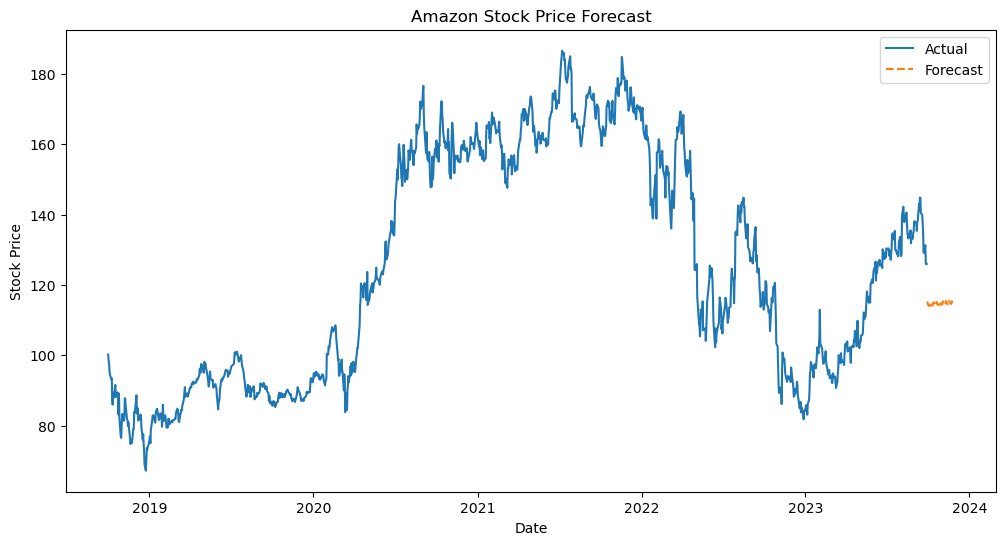

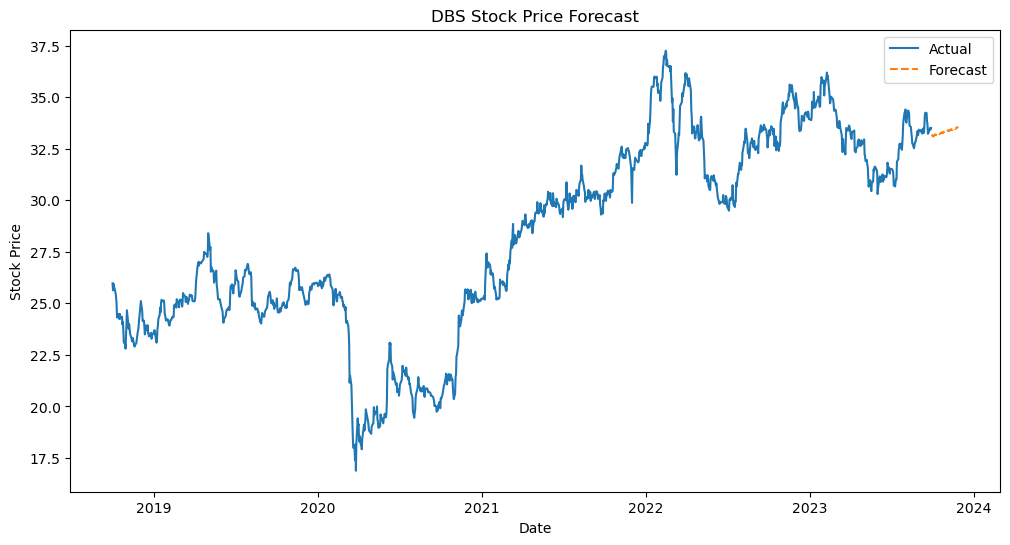

In [33]:
# Fit SARIMAX with the best seasonal order and check residuals
def fit_sarimax_with_residuals(stock, stock_df, train_size, seasonal_orders_grid):
    # Split into train and test sets
    train, test = stock_df[:train_size], stock_df[train_size:]

    best_seasonal_order = None
    best_rmse = float('inf')

    # Perform grid search for the best seasonal order
    for seasonal_order in seasonal_orders_grid:
        # Fit SARIMAX model with current seasonal order
        model = SARIMAX(train, order=(2, 1, 1), seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)

        # Evaluate model on test data
        predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
        rmse = np.sqrt(mean_squared_error(test, predictions))

        # Update the best seasonal order based on RMSE
        if rmse < best_rmse:
            best_rmse = rmse
            best_seasonal_order = seasonal_order

    # Fit the final model with the best seasonal order
    model = SARIMAX(train, order=(2, 1, 1), seasonal_order=best_seasonal_order)
    model_fit = model.fit(disp=False)

    # Forecast the next 60 days (future)
    forecast = model_fit.get_forecast(steps=60)
    forecast_mean = forecast.predicted_mean

    # Evaluate on test data
    predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
    
    # Calculate MAE and RMSE
    mae = mean_absolute_error(test, predictions)

    # Get residuals and plot them
    residuals = test - predictions

    # Plot residuals
    plt.figure(figsize=(10, 5))
    plt.plot(residuals)
    plt.title(f'{stock} Residuals')
    plt.show()

    return stock, model_fit, forecast_mean, mae, best_rmse, residuals

# Run the model and diagnostics for each stock
results = Parallel(n_jobs=-1)(delayed(fit_sarimax_with_residuals)(stock, df[stock], train_size, seasonal_orders_grid) for stock in stocks)

# Storing the results in a dictionary
results_dict = {}
for result in results:
    stock, model_fit, forecast_mean, mae, best_rmse, residuals = result
    results_dict[stock] = {
        'model': model_fit,
        'forecast': forecast_mean,
        'mae': mae,
        'rmse': best_rmse,
        'residuals': residuals
    }

# Print results for each stock
for stock, result in results_dict.items():
    print(f"{stock} - Best Seasonal Order: {result['model'].model.seasonal_order} - MAE: {result['mae']}, RMSE: {result['rmse']}")
    print("=" * 50)

# Plot results (actual vs forecast)
for stock, result in results_dict.items():
    plt.figure(figsize=(12, 6))

    # Plot actual data
    plt.plot(df.index, df[stock], label='Actual')

    # Create a date range starting from the last training data point and extending to 60 days beyond
    forecast_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=60, freq='D')

    # Plot forecasted data (next 60 days)
    plt.plot(forecast_dates, result['forecast'], label='Forecast', linestyle='--')

    # Formatting the plot
    plt.title(f"{stock} Stock Price Forecast")
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()


## 4. Evaluation

We evaluate each model using:
- **MAE** (Mean Absolute Error) — average prediction error in dollars
- **RMSE** (Root Mean Squared Error) — penalises larger errors more
- **MAPE** (Mean Absolute Percentage Error) — percentage error, useful
  for comparing across stocks with different price scales

DBS achieved the lowest MAPE (1.97%), reflecting its more stable price range
compared to Apple (15.6%) and Amazon (14.4%).

In [34]:
from sklearn.metrics import mean_absolute_percentage_error

# Evaluating the model using MAPE
for stock, result in results_dict.items():
    # Calculate MAPE for the forecasted data
    mape = mean_absolute_percentage_error(df[stock][-60:], result['forecast'])  # Assuming last 60 days of actual data for comparison
    
    print(f"{stock} - MAPE: {mape}")

Apple - MAPE: 0.15643005900453544
Amazon - MAPE: 0.14431221579707387
DBS - MAPE: 0.019709939944649393


## 5. Residual Analysis

We plot model residuals to check whether errors are randomly distributed
around zero (a sign of a well-fitted model). A histogram of residuals
checks for approximate normality.

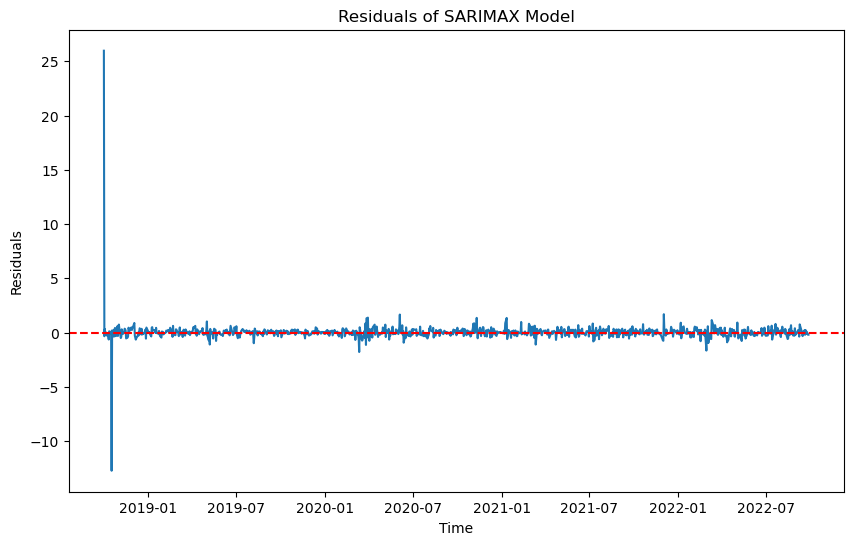

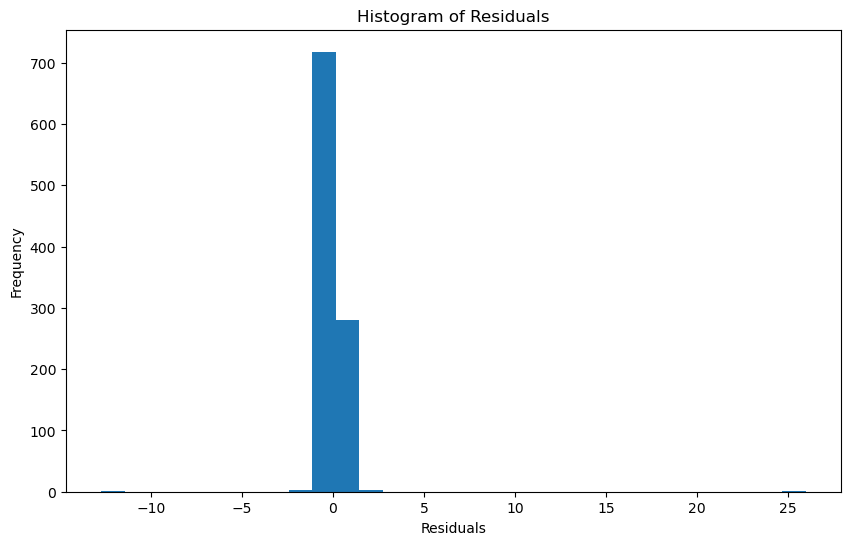

In [35]:
import matplotlib.pyplot as plt

# Assuming 'model' is your SARIMAX model and 'results' is the fitted model from model.fit()
results = model.fit()

# Get residuals from the results
residuals = results.resid

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title('Residuals of SARIMAX Model')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')  # Adding a line at 0 for reference
plt.show()

# Optional: Plot histogram of residuals to check for normality
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()
